In [52]:
!pip install contextily

In [84]:
!pip install geopandas contextily folium matplotlib seaborn scikit-learn

In [55]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [85]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import folium
from folium.plugins import HeatMap
import geopandas as gpd
import contextily as ctx
from mpl_toolkits.axes_grid1 import make_axes_locatable
from shapely.geometry import Point

In [57]:
df = pd.read_csv('/content/drive/MyDrive/Mecine Learning/Praktikum11/data/housing.csv')
df.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY


In [86]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 15 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           20640 non-null  float64
 1   latitude            20640 non-null  float64
 2   housing_median_age  20640 non-null  float64
 3   total_rooms         20640 non-null  float64
 4   total_bedrooms      20640 non-null  float64
 5   population          20640 non-null  float64
 6   households          20640 non-null  float64
 7   median_income       20640 non-null  float64
 8   median_house_value  20640 non-null  float64
 9   ocean_proximity     20640 non-null  object 
 10  lat_j               20640 non-null  float64
 11  lon_j               20640 non-null  float64
 12  cluster             20640 non-null  int64  
 13  pca1                20640 non-null  float64
 14  pca2                20640 non-null  float64
dtypes: float64(13), int64(1), object(1)
memory usage: 2.4

In [59]:
df.isnull().sum()

,0
longitude,0
latitude,0
housing_median_age,0
total_rooms,0
total_bedrooms,207
population,0
households,0
median_income,0
median_house_value,0
ocean_proximity,0


In [60]:
df.duplicated().sum()

np.int64(0)

In [61]:
df['total_bedrooms'] = df['total_bedrooms'].fillna(df['total_bedrooms'].mean())

In [62]:
df.isnull().sum()

,0
longitude,0
latitude,0
housing_median_age,0
total_rooms,0
total_bedrooms,0
population,0
households,0
median_income,0
median_house_value,0
ocean_proximity,0


In [90]:
coords = df[['latitude', 'longitude']].dropna().values.tolist()
len(coords)

20640

In [64]:
m = folium.Map(
    location=[df['latitude'].mean(), df['longitude'].mean()],
    zoom_start=11 # kalau kota → 11, kalau negara → 5–6
)

HeatMap(coords, radius=8).add_to(m)
m

In [65]:
df['lat_j'] = df['latitude'] + np.random.normal(0, 0.0005, len(df))
df['lon_j'] = df['longitude'] + np.random.normal(0, 0.0005, len(df))

coords_jitter = df[['lat_j', 'lon_j']].values.tolist()

m2 = folium.Map(location=[df['lat_j'].mean(), df['lon_j'].mean()], zoom_start=11)
HeatMap(coords_jitter, radius=8).add_to(m2)
m2

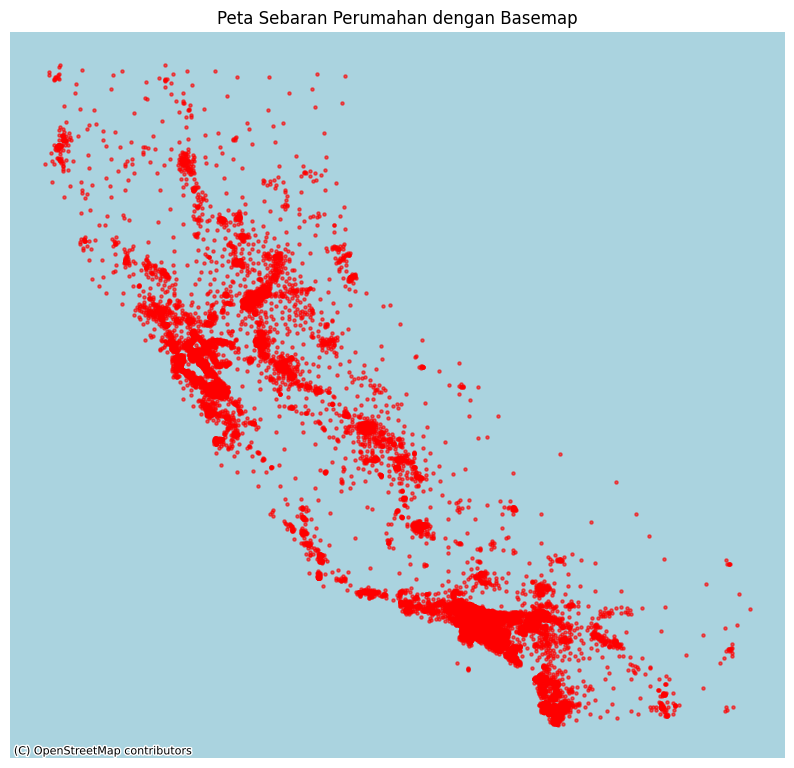

In [66]:
import geopandas
from shapely.geometry import Point

geometry = [Point(xy) for xy in zip(df['longitude'], df['latitude'])]
gdf = geopandas.GeoDataFrame(df, geometry=geometry)

fig, ax = plt.subplots(figsize=(10, 10))

gdf.plot(ax=ax, alpha=0.6, markersize=5, color='red')

ctx.add_basemap(ax, source=ctx.providers.OpenStreetMap.Mapnik, zoom=12)

ax.set_axis_off()
plt.title("Peta Sebaran Perumahan dengan Basemap")
plt.show()

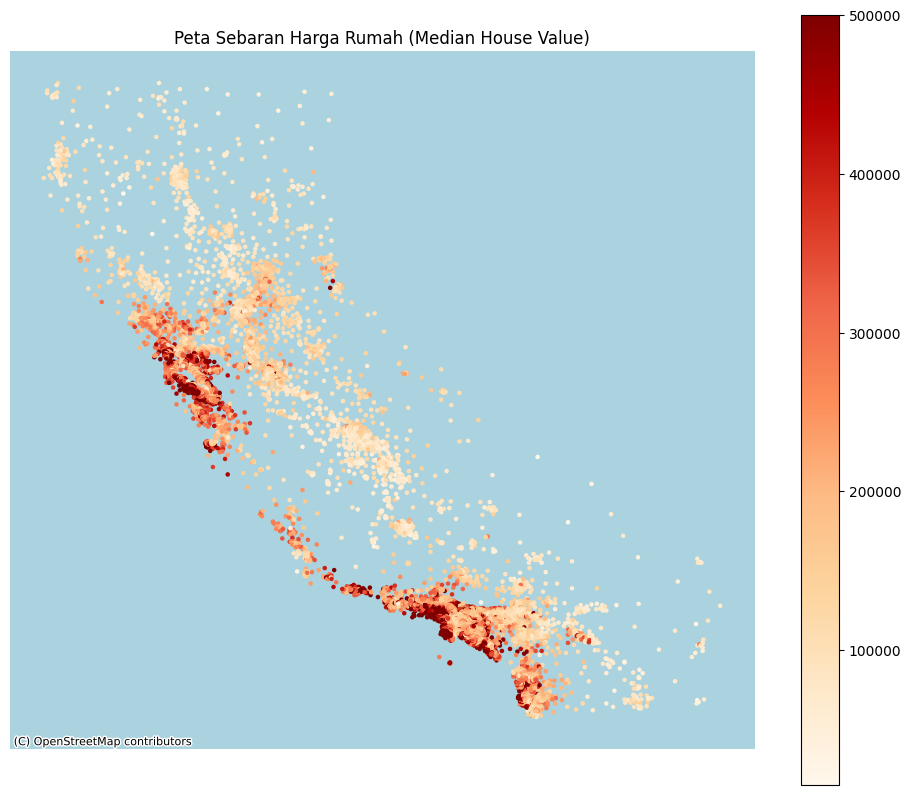

In [67]:
import matplotlib.pyplot as plt
from mpl_toolkits.axes_grid1 import make_axes_locatable

fig, ax = plt.subplots(figsize=(12, 10))

# plot peta titik (warna mengikuti price)
gdf.plot(
    ax=ax,
    column='median_house_value',
    cmap='OrRd',      # orange → red
    markersize=5,
    legend=True
)

# tambah basemap
ctx.add_basemap(ax, source=ctx.providers.OpenStreetMap.Mapnik, zoom=12)

ax.set_title("Peta Sebaran Harga Rumah (Median House Value)")
ax.set_axis_off()

plt.show()

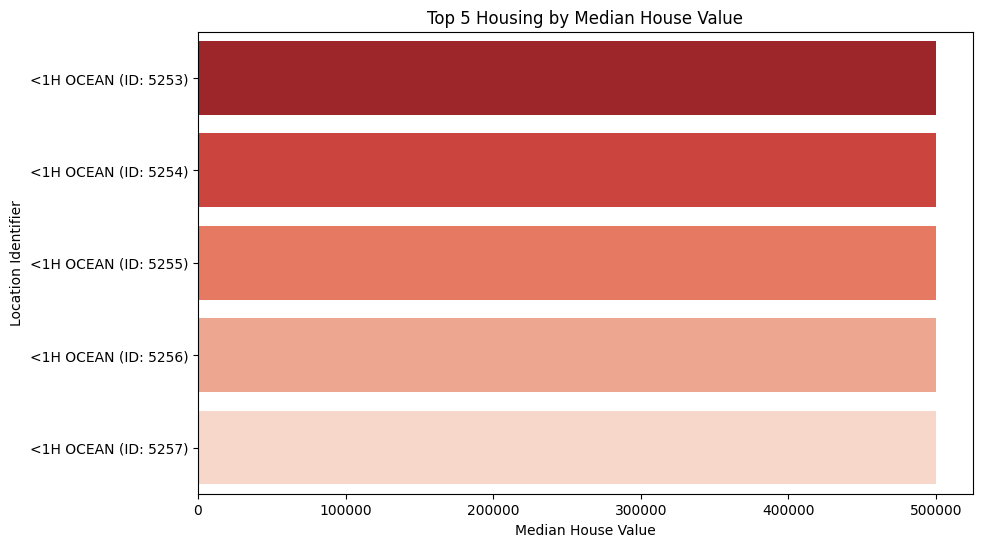

In [68]:
top5_highest_value_houses = df.sort_values('median_house_value', ascending=False).head(5)

# Create a 'display_label' by combining ocean_proximity and the original index for unique identification
top5_highest_value_houses['display_label'] = top5_highest_value_houses['ocean_proximity'] + ' (ID: ' + top5_highest_value_houses.index.astype(str) + ')'

plt.figure(figsize=(10,6)) # Adjust figure size for better readability
sns.barplot(data=top5_highest_value_houses, x='median_house_value', y='display_label', hue='display_label', palette='Reds_r', legend=False)
plt.title("Top 5 Housing by Median House Value")
plt.xlabel("Median House Value")
plt.ylabel("Location Identifier")
plt.show()

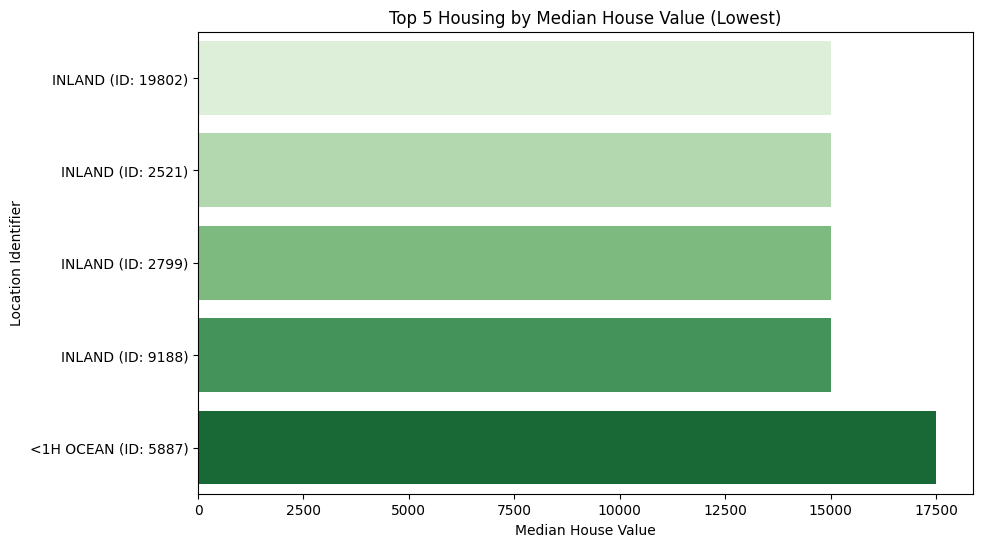

In [69]:
top5_lowest_value_houses = df.sort_values('median_house_value', ascending=True).head(5)

# Create a 'display_label' by combining ocean_proximity and the original index for unique identification
top5_lowest_value_houses['display_label'] = top5_lowest_value_houses['ocean_proximity'] + ' (ID: ' + top5_lowest_value_houses.index.astype(str) + ')'

plt.figure(figsize=(10,6)) # Adjust figure size for better readability
sns.barplot(data=top5_lowest_value_houses, x='median_house_value', y='display_label', hue='display_label', palette='Greens', legend=False)
plt.title("Top 5 Housing by Median House Value (Lowest)")
plt.xlabel("Median House Value")
plt.ylabel("Location Identifier")
plt.show()

In [92]:
from scipy.stats import shapiro

# Cek Normalitas Harga Rumah
stat, p = shapiro(df['median_house_value'])
print(f"P-value Shapiro: {p}")
if p > 0.05:
    print("Data Normal")
else:
    print("Data TIDAK Normal (Gunakan korelasi Spearman)")

P-value Shapiro: 1.3673019915893023e-74
Data TIDAK Normal (Gunakan korelasi Spearman)


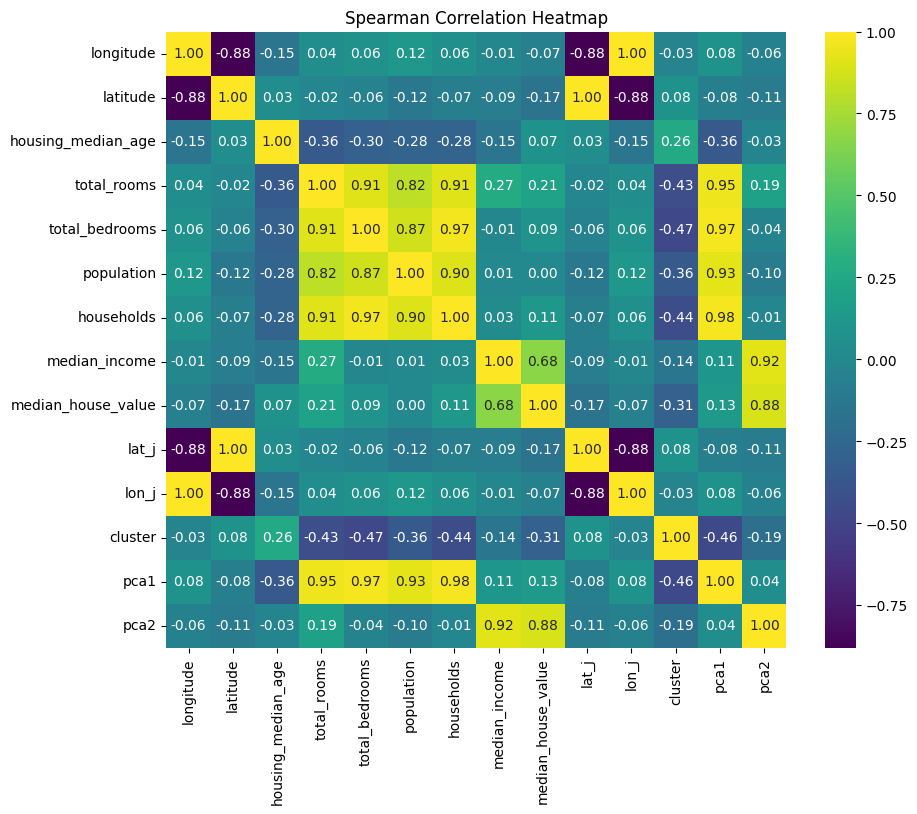

In [93]:
corr_df = df.select_dtypes(include=np.number)
spearman_corr = corr_df.corr(method='spearman')

plt.figure(figsize=(10, 8))
sns.heatmap(spearman_corr, annot=True, cmap='viridis', fmt=".2f")
plt.title("Spearman Correlation Heatmap")
plt.show()

In [94]:
from sklearn.preprocessing import RobustScaler

# Kolom yang akan dicluster (Bukan cuma Lokasi, tapi juga harga, jumlah kamar, dll)
cols_for_clustering = [
    'housing_median_age', 'total_rooms', 'total_bedrooms',
    'population', 'households', 'median_income', 'median_house_value'
]

X = df[cols_for_clustering].copy()

# Scaling
scaler = RobustScaler()
X_scaled = scaler.fit_transform(X)
X_scaled = pd.DataFrame(X_scaled, columns=cols_for_clustering)

print("Data berhasil di-scaling!")

Data berhasil di-scaling!


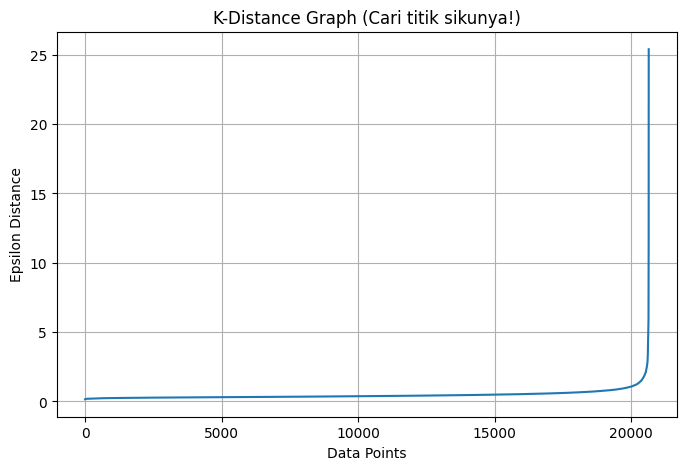

Jarak terjauh: [ 4.49263433  4.6537417   4.73455135  4.73912736  4.9714277   5.199169
  5.25918497  5.41821391  5.65502006  5.76873765  5.8186012   5.90278789
  6.53526292  6.5738953   6.96016389  8.37537715 10.63752449 11.83670644
 20.68748868 25.40833029]


In [96]:
from sklearn.neighbors import NearestNeighbors

min_samples = 10
neighbors = NearestNeighbors(n_neighbors=min_samples)
neighbors_fit = neighbors.fit(X_scaled)
distances, indices = neighbors_fit.kneighbors(X_scaled)

distances = np.sort(distances[:, -1])

plt.figure(figsize=(8,5))
plt.plot(distances)
plt.title("K-Distance Graph (Cari titik sikunya!)")
plt.xlabel("Data Points")
plt.ylabel("Epsilon Distance")
plt.grid(True)
plt.show()

# Lihat jarak terjauh (hanya untuk info)
print("Jarak terjauh:", distances[-20:])

In [97]:
from sklearn.preprocessing import RobustScaler

scaler = RobustScaler()
X_scaled = scaler.fit_transform(X)

# ubah ke DataFrame biar rapi
X_scaled = pd.DataFrame(X_scaled, columns=cols_for_clustering)

X_scaled.head()

,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
0,0.631579,-0.733422,-0.892419,-0.899787,-0.870769,2.197582,1.880448
1,-0.421053,2.924276,1.929242,1.316631,2.243077,2.186664,1.232041
2,1.210526,-0.388178,-0.716245,-0.714286,-0.713846,1.707732,1.187941
3,1.210526,-0.501691,-0.586282,-0.648188,-0.584615,0.967177,1.113523
4,1.210526,-0.294074,-0.456318,-0.640725,-0.461538,0.142854,1.119724


In [75]:
distances[-20:]

array([ 4.49263433,  4.6537417 ,  4.73455135,  4.73912736,  4.9714277 ,
        5.199169  ,  5.25918497,  5.41821391,  5.65502006,  5.76873765,
        5.8186012 ,  5.90278789,  6.53526292,  6.5738953 ,  6.96016389,
        8.37537715, 10.63752449, 11.83670644, 20.68748868, 25.40833029])

In [76]:
from sklearn.cluster import DBSCAN

dbscan = DBSCAN(eps=0.30, min_samples=10)
labels = dbscan.fit_predict(X_scaled)

labels[:20]  # lihat sample hasil cluster

array([-1, -1, -1, -1,  0,  0, 10, -1, -1, -1, -1, -1, -1,  0, -1,  0,  0,
        0,  0,  0])

In [77]:
df['cluster'] = labels
df['cluster'].value_counts()

,count
cluster,
-1,12410
0,7764
10,53
2,31
11,31
5,27
9,22
18,18
15,18


In [78]:
from sklearn.metrics import silhouette_score

# silhouette hanya dihitung untuk cluster bukan -1
mask = df['cluster'] != -1
sil_score = silhouette_score(X_scaled[mask], df['cluster'][mask])

sil_score

np.float64(-0.32840557473339704)

In [79]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
pca_results = pca.fit_transform(X_scaled)

df['pca1'] = pca_results[:, 0]
df['pca2'] = pca_results[:, 1]

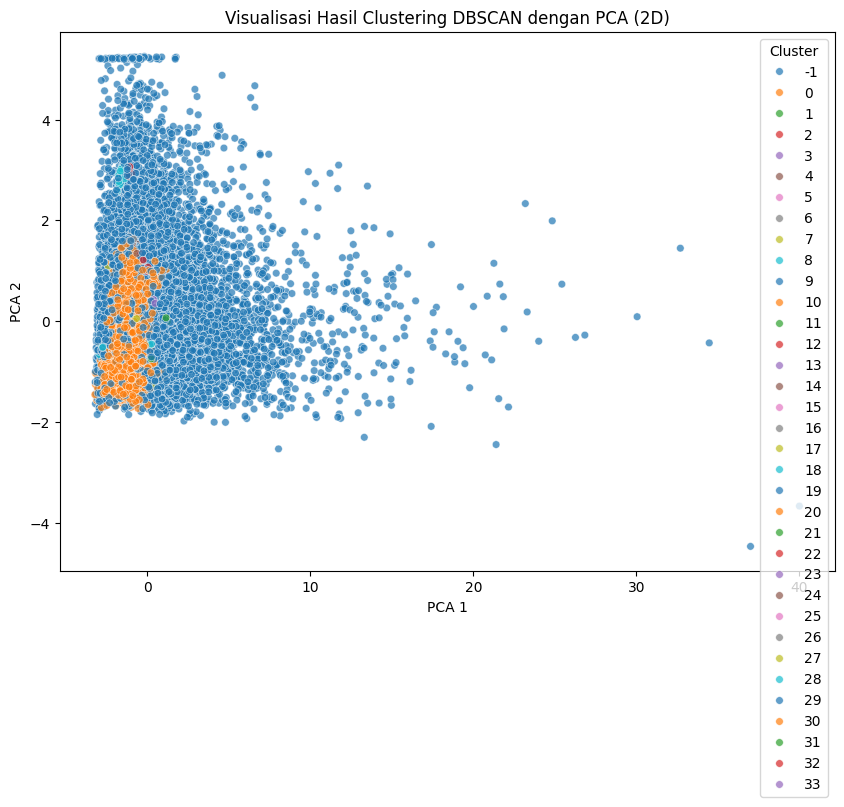

In [80]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 7))
sns.scatterplot(
    data=df,
    x='pca1',
    y='pca2',
    hue='cluster',
    palette='tab10',
    s=30,
    alpha=0.7
)

plt.title("Visualisasi Hasil Clustering DBSCAN dengan PCA (2D)")
plt.xlabel("PCA 1")
plt.ylabel("PCA 2")
plt.legend(title='Cluster')
plt.show()

In [81]:
import geopandas as gpd

gdf = gpd.GeoDataFrame(
    df,
    geometry=gpd.points_from_xy(df['longitude'], df['latitude']),
    crs='EPSG:4326'
)

In [82]:
gdf = gdf.to_crs(epsg=3857)

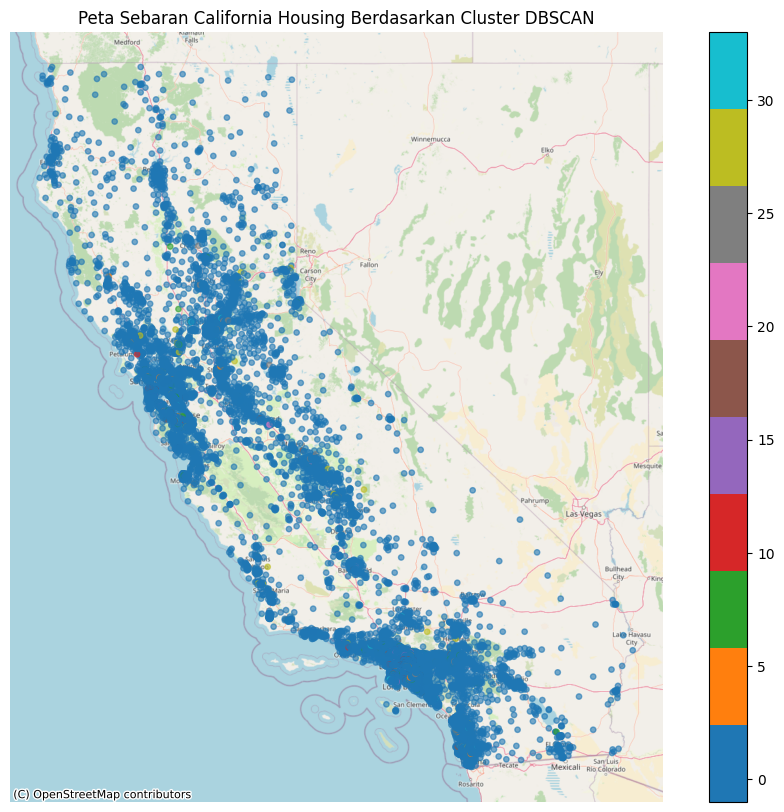

In [99]:
import geopandas as gpd

# Konversi ke GeoDataFrame
gdf = gpd.GeoDataFrame(
    df,
    geometry=gpd.points_from_xy(df['longitude'], df['latitude']),
    crs='EPSG:4326' # Koordinat GPS standar
)

# Ubah ke Web Mercator (Biar pas sama peta background)
gdf = gdf.to_crs(epsg=3857)

# Plotting
fig, ax = plt.subplots(figsize=(12, 10))

# Plot Cluster
gdf.plot(
    ax=ax,
    column='cluster',
    cmap='tab10',
    markersize=15,
    legend=True,
    alpha=0.6
)

# Tambah Basemap (Peta Jalanan)
try:
    ctx.add_basemap(ax, source=ctx.providers.OpenStreetMap.Mapnik)
except:
    print("Gagal memuat basemap (cek koneksi internet), menampilkan titik saja.")

ax.set_title("Peta Sebaran California Housing Berdasarkan Cluster DBSCAN")
ax.set_axis_off()
plt.show()